In [2]:
import scipp as sc
import numpy as np
from racf_models_ns import *
import pickle
from dynesty.utils import Results
from kinisi.arrhenius import Arrhenius
import matplotlib.pyplot as plt
from corner import corner

In [3]:
temperatures = np.array([190,240,290,310])
Ds = {'mean' : [], 'var' : []}
Dt = {'mean' : [], 'var' : []}

In [4]:
temps = ['190_M', '240_M', '290_M', '310_M']

In [5]:
for temp in temps:  
    max_logz_list = []
    for name in names:
        file_name = f'data/racf/ns/{temp}/{name}.pkl'
        with open(file_name, 'rb') as file:
            data = pickle.load(file)
        res = Results(data)
        max_logz_list.append(res['logz'][-1])
    max_arr = np.array(max_logz_list)

    max_of_max = max_arr.max()
    position_of_max_z = max_logz_list.index(max_of_max)
    best_model = names[position_of_max_z]
        
    file_name = f'data/racf/ns/{temp}/{best_model}.pkl'
    with open(file_name, 'rb') as file:
        data = pickle.load(file)
    res = Results(data)
    Ds['mean'].append(res.samples_equal()[:,0].mean())
    Ds['var'].append(res.samples_equal()[:,0].var())
    Dt['mean'].append(res.samples_equal()[:,1].mean())
    Dt['var'].append(res.samples_equal()[:,1].var())

In [6]:
tds = sc.DataArray(
    data=sc.array(dims=['temperature'],
                  values=Ds['mean'],
                  variances=Ds['var'],
                  unit='cm^2/s',),
    coords={'temperature': sc.Variable(dims=['temperature'],
                                    values=temperatures,
                                    unit='K')
    })
tds

<scipp.DataArray>
Dimensions: Sizes[temperature:4, ]
Coordinates:
* temperature                 int64              [K]  (temperature)  [190, 240, 290, 310]
Data:
                            float64         [cm^2/s]  (temperature)  [0.1206, 0.134727, 0.147822, 0.146219]  [5.01939e-09, 6.91672e-09, 1.47894e-08, 1.56618e-08]

In [7]:
tdt = sc.DataArray(
    data=sc.array(dims=['temperature'],
                  values=Dt['mean'],
                  variances=Dt['var'],
                  unit='cm^2/s',),
    coords={'temperature': sc.Variable(dims=['temperature'],
                                    values=temperatures,
                                    unit='K')
    })
tdt

<scipp.DataArray>
Dimensions: Sizes[temperature:4, ]
Coordinates:
* temperature                 int64              [K]  (temperature)  [190, 240, 290, 310]
Data:
                            float64         [cm^2/s]  (temperature)  [0.033848, 0.0506688, 0.0644205, 0.0692954]  [2.19603e-10, 4.9272e-10, 2.00474e-09, 2.25096e-09]

MCMC Sampling:   8%|▊         | 115/1500 [00:00<00:07, 184.99it/s]

MCMC Sampling: 100%|██████████| 1500/1500 [00:07<00:00, 209.14it/s]


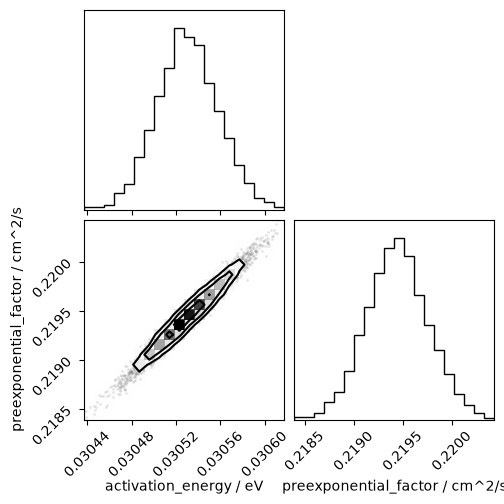

In [8]:
s = Arrhenius(tdt, bounds=[[0.01 * sc.Unit('eV'), 0.04 * sc.Unit('eV')],
                           [0.1 * sc.Unit('cm^2/s'), 0.4 * sc.Unit('cm^2/s')]])
s.mcmc()
corner(np.array([i.values for i in s.flatchain.values()]).T,
         labels=[' / ' .join([k, str(v.unit)]) for k, v in s.flatchain.items()])
plt.show()

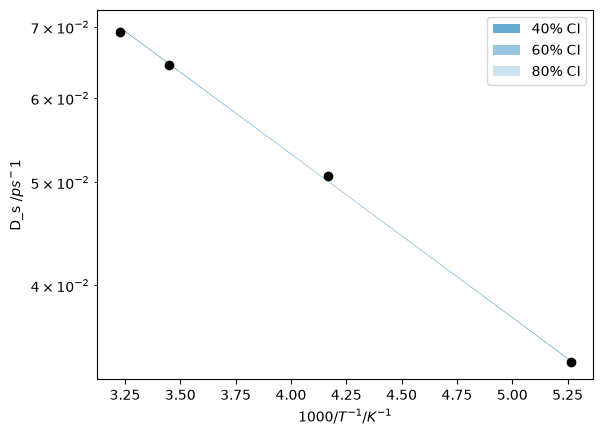

In [9]:
credible_intervals = [[2.5, 97.5], [16, 84], [50, 50]]
alpha = [0.6, 0.4, 0.2]

plt.errorbar(1000 / tdt.coords['temperature'].values,
              tdt.data.values,
                yerr=np.sqrt(tdt.data.variances),
                marker='o',
                ls='',
                color='k',
                zorder=10)

for i, ic in enumerate(credible_intervals):
    plt.fill_between(1000 / tdt.coords['temperature'].values,
                     *np.percentile(s.distribution, ic, axis=1),
                        alpha=alpha[i],
                    lw=0,
                     color='#0173B2',
                     label=f'{int((1-alpha[i])*100)}% CI')
plt.xlabel('$1000/T^{-1}$/$K^{-1}$')
plt.ylabel('D_s /$ps{^-1}$')
plt.yscale('log')
plt.legend()

MCMC Sampling:  11%|█         | 167/1500 [00:00<00:06, 203.95it/s]

MCMC Sampling: 100%|██████████| 1500/1500 [00:06<00:00, 215.80it/s]


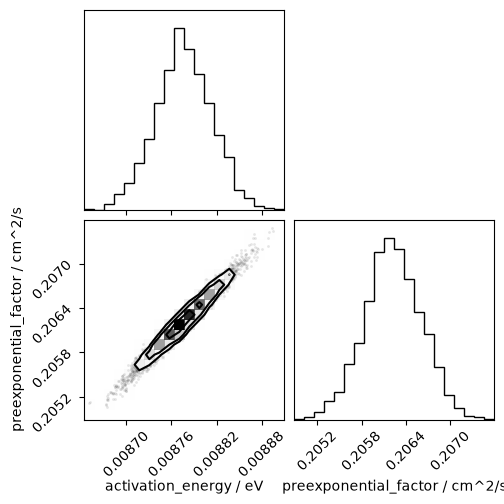

In [10]:
s = Arrhenius(tds, bounds=[[0.005 * sc.Unit('eV'), 0.011 * sc.Unit('eV')],
                           [0.1 * sc.Unit('cm^2/s'), 0.4 * sc.Unit('cm^2/s')]])
s.mcmc()
corner(np.array([i.values for i in s.flatchain.values()]).T,
         labels=[' / ' .join([k, str(v.unit)]) for k, v in s.flatchain.items()])
plt.show()

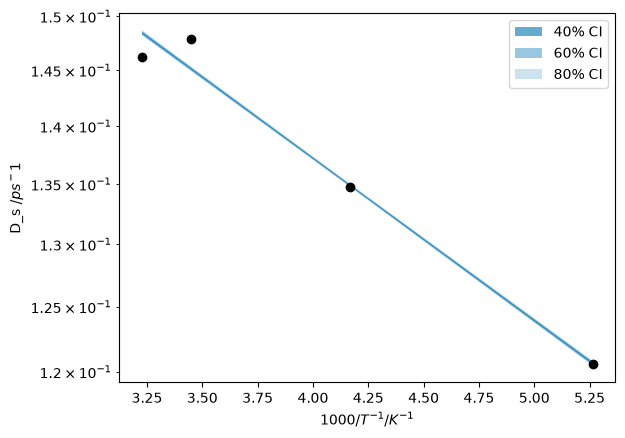

In [11]:
credible_intervals = [[16, 84], [2.5, 97.5], [0.15, 99.85]]
alpha = [0.6, 0.4, 0.2]

plt.errorbar(1000 / tds.coords['temperature'].values,
              tds.data.values,
                yerr=np.sqrt(tds.data.variances),
                marker='o',
                ls='',
                color='k',
                zorder=10)

for i, ic in enumerate(credible_intervals):
    plt.fill_between(1000 / tds.coords['temperature'].values,
                     *np.percentile(s.distribution, ic, axis=1),
                        alpha=alpha[i],
                    lw=0,
                     color='#0173B2',
                     label=f'{int((1-alpha[i])*100)}% CI')
plt.xlabel('$1000/T^{-1}$/$K^{-1}$')
plt.ylabel('D_s /$ps{^-1}$')
plt.yscale('log')
plt.legend()

Intercept: -1.5800579501826835, Slope: -101.4627721136309


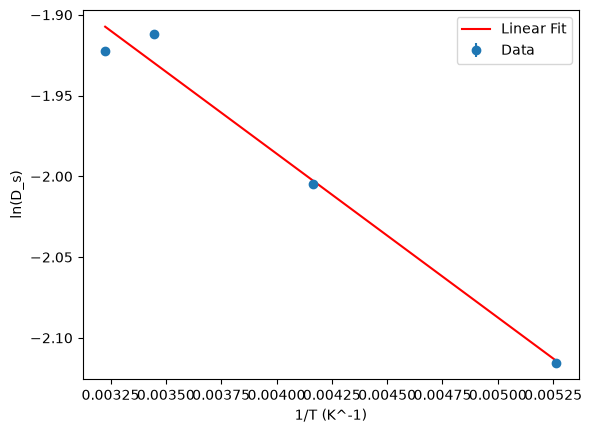

pre-exponential factor for D_t: 0.2059631622561628
activation energy for D_t: 0.008743385210042297


In [14]:
from sklearn.linear_model import LinearRegression

x = 1 / tds.coords['temperature'].values.reshape(-1, 1)
y = np.log(tds.values).reshape(-1, 1)

model = LinearRegression()
model.fit(x, y)

y_pred = model.predict(x)
print(f"Intercept: {model.intercept_[0]}, Slope: {model.coef_[0][0]}")

recip_temp = 1 / tds.coords['temperature'].values
ln_D = np.log(tds.values)
plt.errorbar(recip_temp, ln_D, yerr=np.sqrt(tds.variances), fmt='o', label='Data')
plt.plot(recip_temp, y_pred, color='red', label='Linear Fit')
plt.xlabel('1/T (K^-1)')
plt.ylabel('ln(D_s)')
plt.legend()
plt.show() 

k_B = 8.617333262145e-5  # Boltzmann constant in eV/K


print("pre-exponential factor for D_t:", np.exp(model.intercept_[0]))
print("activation energy for D_t:", -model.coef_[0][0] * k_B)

Intercept: -1.528267440232359, Slope: -351.8990318843316


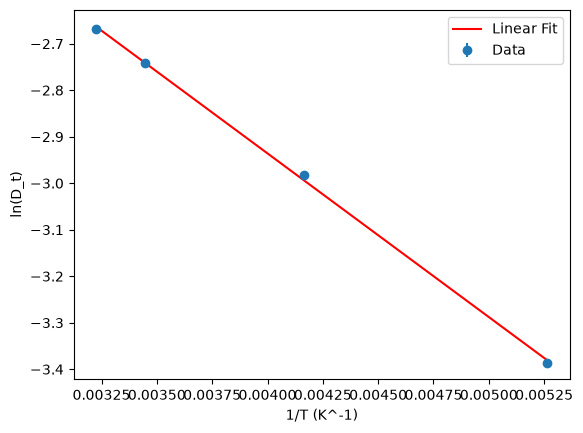

pre-exponential factor for D_t: 0.21691115348364504
activation energy for D_t: 0.030324312323734743


In [13]:
x = 1 / tdt.coords['temperature'].values.reshape(-1, 1)
y = np.log(tdt.values).reshape(-1, 1)

model = LinearRegression()
model.fit(x, y)

y_pred = model.predict(x)
print(f"Intercept: {model.intercept_[0]}, Slope: {model.coef_[0][0]}")

recip_temp = 1 / tdt.coords['temperature'].values
ln_D = np.log(tdt.values)
plt.errorbar(recip_temp, ln_D, yerr=np.sqrt(tdt.variances), fmt='o', label='Data')
plt.plot(recip_temp, y_pred, color='red', label='Linear Fit')
plt.xlabel('1/T (K^-1)')
plt.ylabel('ln(D_t)')
plt.legend()
plt.show()  

k_B = 8.617333262145e-5  # Boltzmann constant in eV/K

print("pre-exponential factor for D_t:", np.exp(model.intercept_[0]))
print("activation energy for D_t:", -model.coef_[0][0] * k_B)

Text(0.5, 1.0, 'The antistropy rotaional nature of benzene with respect to temperture')

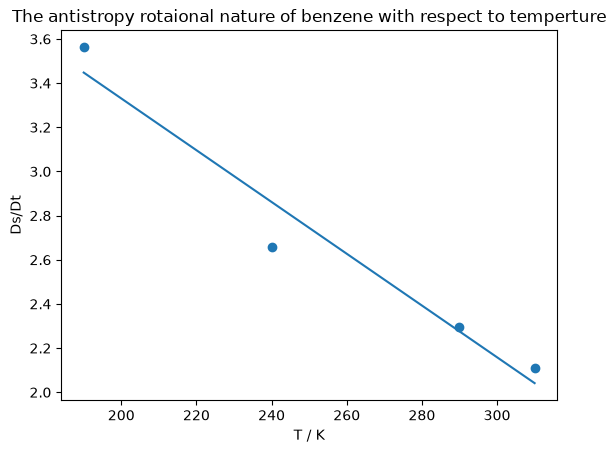

In [27]:
y = tds.values / tdt.values 
x = tdt.coords['temperature'].values.reshape(-1, 1)

model.fit(x,y)

y_pred = model.predict(x)

plt.plot(x, y_pred, label='linear fit')
plt.scatter(x,y, label='data')
plt.xlabel('T / K')
plt.ylabel('Ds/Dt')
plt.title('The antistropy rotaional nature of benzene with respect to temperture')